Following era5cubes.ipynb, let's try with another day with clouds at higher altitudes

In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt
import cmocean as cmo

import atmo3 as a3
from atmo3 import atm_utils as au

import xarray as xr
import pandas as pd


In [2]:
from matplotlib import pyplot as plt
# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})

In [3]:
# Turbulence injection scales: the wavenumber k0 = 2π/L_inj marks the peak
# of the power spectrum, i.e. the scale at which turbulent energy is injected.
q_injection_scale_in_m  = 500.0  # Water-vapour injection scale (m)
ta_injection_scale_in_m = 200.0  # Temperature injection scale (m)

# Grid dimensions [Nx, Ny, Nz] and physical box size [Lx, Ly, Lz] in metres.
# The horizontal resolution is Lx/Nx ≈ 39 m; the vertical is Lz/Nz ≈ 39 m.
nside_grid = [256, 256, 256]
box_length = [20000., 20000., 20000.]

# APEX observatory: altitude 5100 m a.s.l., Llano de Chajnantor, Chile.
site_altitude = 5100.
site_coordinates = [-67.78, -22.95]  # [longitude, latitude] in degrees

# Simulation epoch in UTC.  ERA5 profiles and APEX weather data are
# selected from a ±30-minute window centred on this timestamp.
time_utc = datetime(2023, 9, 12, 20, 0, tzinfo=timezone.utc)

# =============================================================================
# Input data paths
# =============================================================================

atmo3_data = '/pscratch/sd/s/shamikg/atmo3_data/'

# ERA5 pressure-level files covering the APEX region (291–293 °E, 24–22 °S)
# at 0.25° resolution for September 2023.
geopotfile = f'{atmo3_data}era5/2023/geopt.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
tempfile   = f'{atmo3_data}era5/2023/ta.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
spechfile  = f'{atmo3_data}era5/2023/q.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ccfile     = f'{atmo3_data}era5/2023/cc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
ciwcfile   = f'{atmo3_data}era5/2023/ciwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
clwcfile   = f'{atmo3_data}era5/2023/clwc.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'
rhfile     = f'{atmo3_data}era5/2023/r.202309.ap1e5.291.0_293.0_-24.0_-22.0_025.nc'

# APEX weather-station CSV (columns: UT, PWV, Temperature, Humidity,
# Wind_Dir, Wind_Speed) spanning 2006–2025.
apexfile = f'{atmo3_data}apex/meteo_apex_2006_2025.csv'

atmo_box22sep = a3.Atmosphere(
    nside_grid=nside_grid,
    box_length_in_m=box_length,
    site_altitude=site_altitude,
    site_coordinates=site_coordinates,
    time_utc=time_utc,
    geopotential_file_era5=geopotfile,
    temperature_file_era5=tempfile,
    spec_humidity_file_era5=spechfile,
    apex_datafile=apexfile
)


1.4588524590163932 0.04633567238660865


In [4]:
# 1. Extract the altitude array (in meters)
altitude_profile = atmo_box22sep.super_grid.z
# 2. Extract the calibrated specific humidity profile (in kg/kg) not calibrated
q_interp = atmo_box22sep.super_grid.era5_interp2site(spechfile)
# 3. extratc the temperature profile (in K)
t_interp = atmo_box22sep.super_grid.era5_interp2site(tempfile)
cc_interp = atmo_box22sep.super_grid.era5_interp2site(ccfile)

ciwc_interp = atmo_box22sep.super_grid.era5_interp2site(ciwcfile)
clwc_interp = atmo_box22sep.super_grid.era5_interp2site(clwcfile)

rh_interp = atmo_box22sep.super_grid.era5_interp2site(rhfile)

p_interp = atmo_box22sep.super_grid.pressure

In [5]:
# 1. Calculate Virtual Temperature (K)
# Specific humidity affects air density, so we need the virtual temperature first.
t_v_interp = au.virtual_temperature(T=t_interp, q=q_interp)

# 2. Calculate Water Vapor Density (kg / m^3)
rho_wv_interp = au.water_vapor_density(q=q_interp, P=p_interp, T_v=t_v_interp)

# 3. Integrate over the altitude to get PWV
# We use JAX's trapezoidal integration along the altitude axis (z)
pwv_kg_m2 = jnp.trapezoid(rho_wv_interp, x=altitude_profile)

# 4. Convert units
# 1 kg/m^2 of water is exactly equal to 1 mm of precipitable water!
pwv_mm = pwv_kg_m2

print(f"Calculated ERA5 PWV: {pwv_mm:.3f} mm")

Calculated ERA5 PWV: 1.658 mm


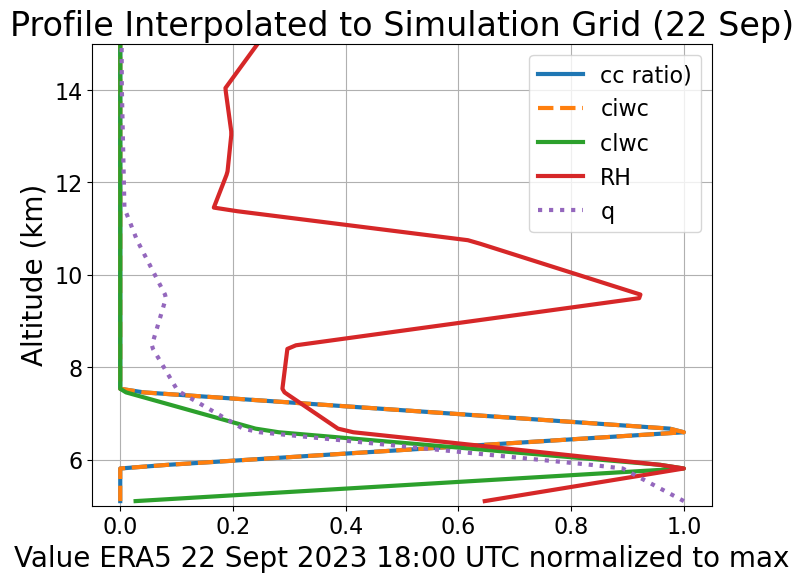

In [8]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp/np.max(cc_interp), altitude_profile/1000, label='cc ratio)')
plt.plot(ciwc_interp*1e3/np.max(ciwc_interp*1e3), altitude_profile/1000, label='ciwc', linestyle='dashed')
plt.plot(clwc_interp*1e3/np.max(clwc_interp*1e3), altitude_profile/1000, label='clwc ')
plt.plot(rh_interp/np.max(rh_interp), altitude_profile/1000, label='RH')
plt.plot(q_interp/np.max(q_interp), altitude_profile/1000, label='q', linestyle='dotted')
plt.xlabel('Value ERA5 22 Sept 2023 18:00 UTC normalized to max')
plt.ylabel('Altitude (km)')
plt.title('Profile Interpolated to Simulation Grid (22 Sep)')
plt.ylim(5, 15)
plt.legend()
plt.grid()
plt.show()

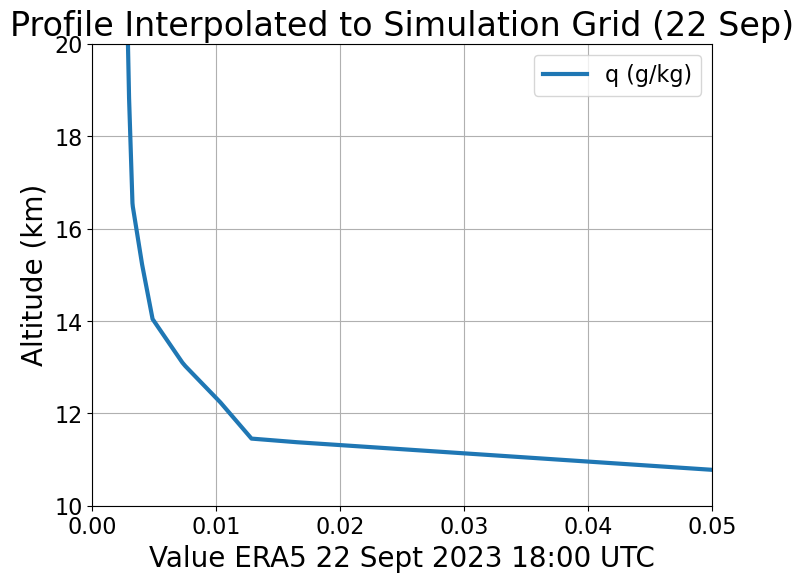

In [7]:
plt.figure(figsize=(8,6))
plt.plot(q_interp*1e3, altitude_profile/1000, label='q (g/kg)')

plt.xlabel('Value ERA5 22 Sept 2023 18:00 UTC')
plt.ylabel('Altitude (km)')
plt.title('Profile Interpolated to Simulation Grid (22 Sep)')
plt.xlim(0, 0.05)
plt.ylim(10, 20)
plt.legend()
plt.grid()
plt.show()

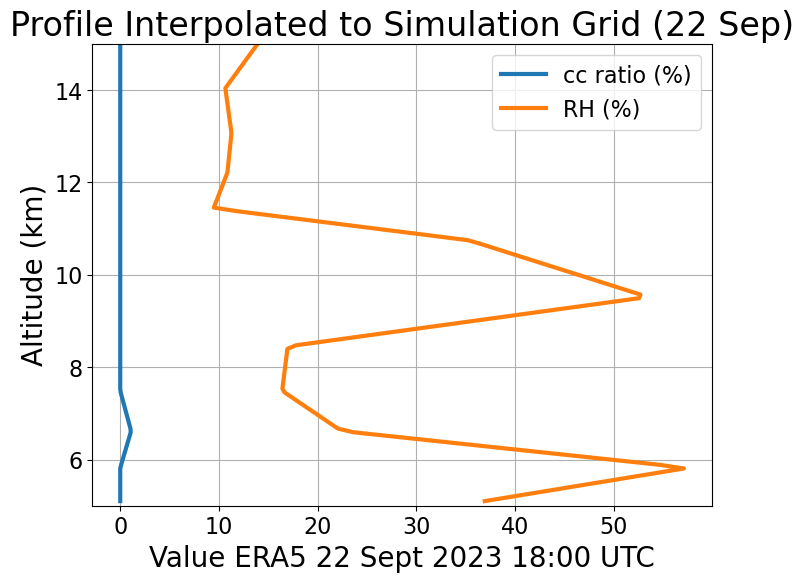

In [10]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp*100, altitude_profile/1000, label='cc ratio (%)')
plt.plot(rh_interp, altitude_profile/1000, label='RH (%)')

plt.xlabel('Value ERA5 22 Sept 2023 18:00 UTC')
plt.ylabel('Altitude (km)')
plt.title('Profile Interpolated to Simulation Grid (22 Sep)')
#plt.ylim(5000, 7500)
plt.ylim(5, 15)
plt.legend()
plt.grid()
plt.show()

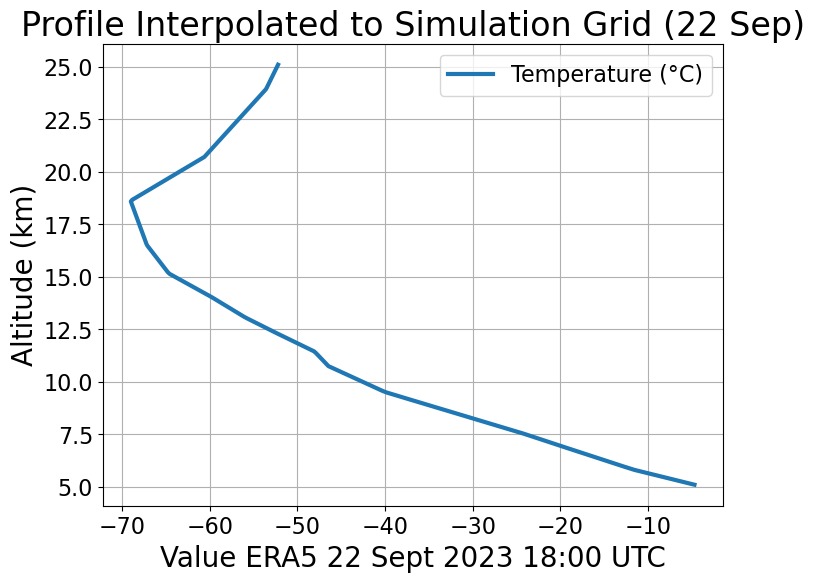

In [11]:
plt.figure(figsize=(8,6))
plt.plot(t_interp - 273.15, altitude_profile/1000, label='Temperature (°C)')
#plt.plot(rh_interp, altitude_profile/1000, label='RH (%)')

plt.xlabel('Value ERA5 22 Sept 2023 18:00 UTC')
plt.ylabel('Altitude (km)')
plt.title('Profile Interpolated to Simulation Grid (22 Sep)')
#plt.ylim(5000, 7500)
plt.legend()
plt.grid()
plt.show()

Let's have some tests on the RH threshold

In [12]:
import jax.numpy as jnp
#from jax import jit



def RH_threshold(T):
    """
    Calculates the physical cloud formation Relative Humidity threshold 
    across all three temperature regimes (Warm, Mixed, Ice).
    
    Parameters:
    -----------
    T : jax.Array
        Temperature in Kelvin (K).
        
    Returns:
    --------
    threshold : jax.Array
        The relative humidity threshold (dimensionless ratio).
    """
    # Phase boundary constants
    T_0 = 273.16    # 0 C (Warm/Mixed boundary)
    T_ice = 235.15  # -38 C (Mixed/Ice boundary)
    
    # 1. Calculate the Ice Phase Threshold (Kärcher and Lohmann)
    rh_homo = 2.583 - (T / 207.8)
    
    # 2. Calculate the Mixed Phase Threshold (e_sat_w / e_sat_i)
    # Tetens formula parameters
    a3_w, a4_w = 17.502, 32.19
    a3_i, a4_i = 22.587, -0.7
    
    # Note: The coefficient a1 (611.21 Pa) is omitted because it perfectly 
    # cancels out when dividing e_sat_w by e_sat_i, saving computation time!
    e_sat_w_base = jnp.exp(a3_w * ((T - T_0) / (T - a4_w)))
    e_sat_i_base = jnp.exp(a3_i * ((T - T_0) / (T - a4_i)))
    
    mixed_ratio = e_sat_w_base / e_sat_i_base
    mixed_threshold = jnp.minimum(rh_homo, mixed_ratio)
    
    # 3. Stitch the regimes together using jnp.where
    # Start by assuming the whole cube is in the Ice Phase
    threshold = rh_homo
    
    # Override with the Mixed Phase threshold where -38C <= T < 0C
    threshold = jnp.where((T >= T_ice) & (T < T_0), mixed_threshold, threshold)
    
    # Override with the Warm Phase threshold (1.0) where T >= 0C
    threshold = jnp.where(T >= T_0, 1.0, threshold)
    
    return threshold

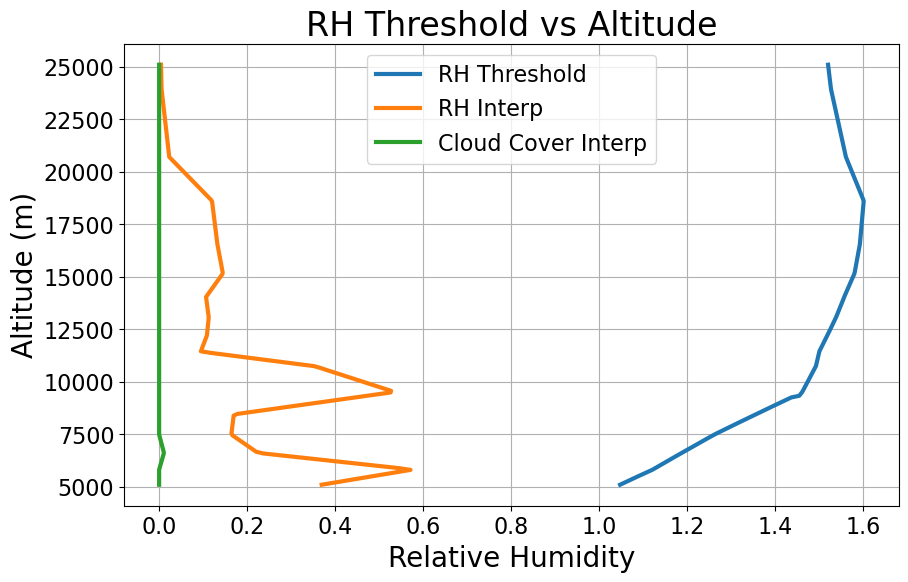

In [13]:
# Let's see the threshold as a function of altitude

rh_threshold_data = RH_threshold(t_interp)

plt.figure(figsize=(10, 6))
plt.plot(rh_threshold_data, altitude_profile, label='RH Threshold')
plt.plot(rh_interp/100, altitude_profile, label='RH Interp')
plt.plot(cc_interp, altitude_profile, label='Cloud Cover Interp')
plt.xlabel('Relative Humidity')
plt.ylabel('Altitude (m)')
plt.title('RH Threshold vs Altitude')
plt.legend()
plt.grid(True)
plt.show()

Let's go back to ERA5 cube

In [14]:

k_array = np.arange(nside_grid[0]) * jnp.min(atmo_box22sep.grid_wsp.dk)

k0_q  = 2*np.pi / q_injection_scale_in_m   # Water-vapour injection wavenumber (rad/m)
k0_ta = 2*np.pi / ta_injection_scale_in_m  # Temperature injection wavenumber (rad/m)

pofk_q  = ( k0_q**2.  + k_array**2 )**-(11/6)
pofk_ta = ( k0_ta**2. + k_array**2 )**-(11/6)

# Normalise to peak = 1; absolute RMS amplitudes come from calibration.
pofk_q  /= np.max(pofk_q)
pofk_ta /= np.max(pofk_ta)

# Pack into dictionaries expected by add_temperature / add_watervapor.
pspec_q  = {'k': k_array, 'pofk': pofk_q}
pspec_ta = {'k': k_array, 'pofk': pofk_ta}


In [15]:
seed = 123456789
atmo_box22sep.add_watervapor(power_spec=pspec_q, seed=seed)

atmo_box22sep.generate_realization(time_step=0, component_name='water vapor')

# Extract your final 3D JAX arrays
rho_water_variations_cube = atmo_box22sep.components['water vapor'].field  # in kg/m^3

mean_dict = atmo_box22sep.component_mean['water vapor']

# The dictionary contains 'h' (height/altitude) and 'f' (the mean values)
rho_water_mean_1d = mean_dict['f'] #in kg/m^3

In [16]:
rho_water_total_3d_grid = rho_water_variations_cube + rho_water_mean_1d.reshape(1,1,-1)

#let's calculate the RH

rh_apex_calibration_fluctuations = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_variations_cube, T=t_interp.reshape(1,1,-1)) * 100.0
rh_apex_calibration_total = au.water_vapor_density_to_rel_humidity(rho_wv=rho_water_total_3d_grid, T=t_interp.reshape(1,1,-1)) * 100.0

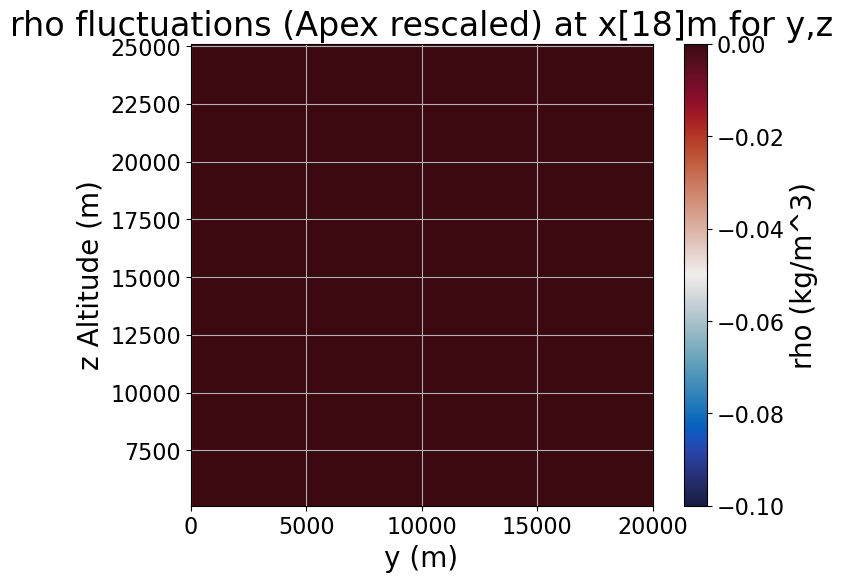

In [17]:
plt.figure(figsize=(8, 6))
plt.imshow(rho_water_total_3d_grid[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower', vmax=0)
plt.colorbar(label='rho (kg/m^3)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('rho fluctuations (Apex rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

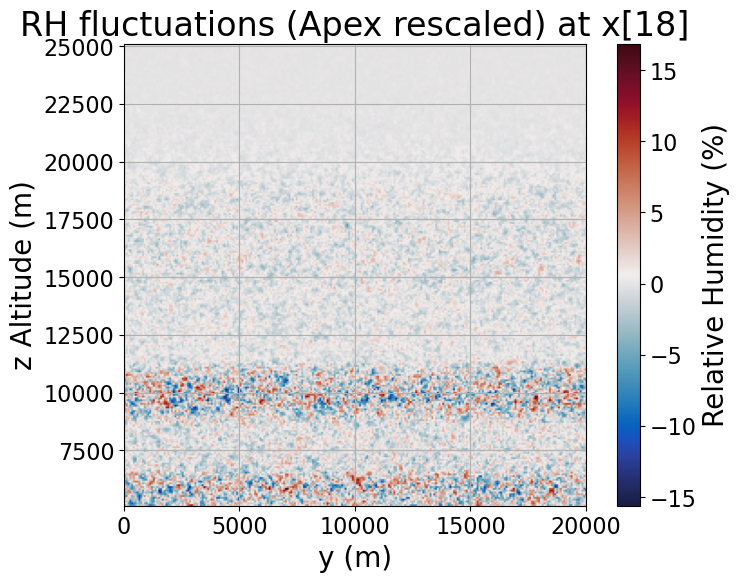

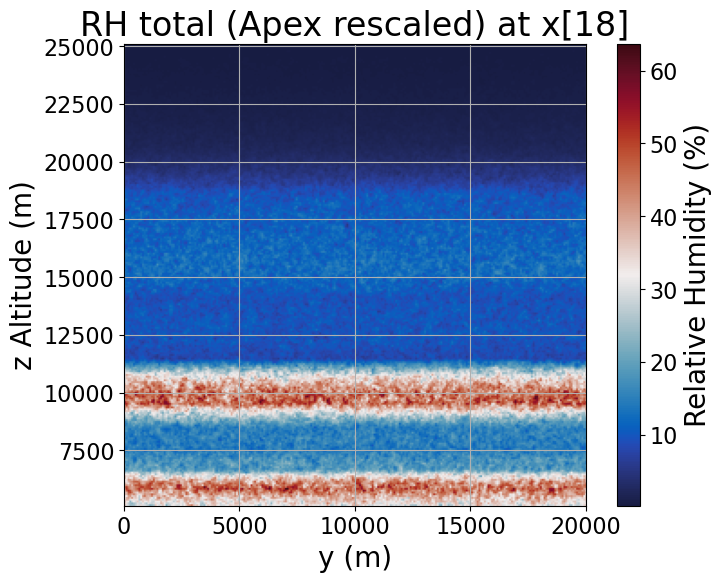

In [18]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_apex_calibration_fluctuations[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (Apex rescaled) at x[18]')
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(rh_apex_calibration_total[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH total (Apex rescaled) at x[18]')
plt.grid()
plt.show()

In [19]:
T_cube =  t_interp.reshape(1,1,-1)  # Reshape to (1, 1, Nz) for broadcasting
# 1. First, generate your 3D threshold cube using your Temperature cube (T_cube)
# (Ensure T_cube has the same dimensions as rh_apex_calibration_total)
dynamic_threshold_cube = RH_threshold(T_cube)

# 2. Replace the hardcoded '1.0' with your new dynamic threshold
cloud_cube_rh_apex_rescaled = (rh_apex_calibration_total / 100.0 > dynamic_threshold_cube).astype(jnp.int32)

# 3. Calculate the mean exactly as you did before
cc_ratio_atmo3_rh_apex_rescaled = jnp.mean(cloud_cube_rh_apex_rescaled, axis=(0,1))

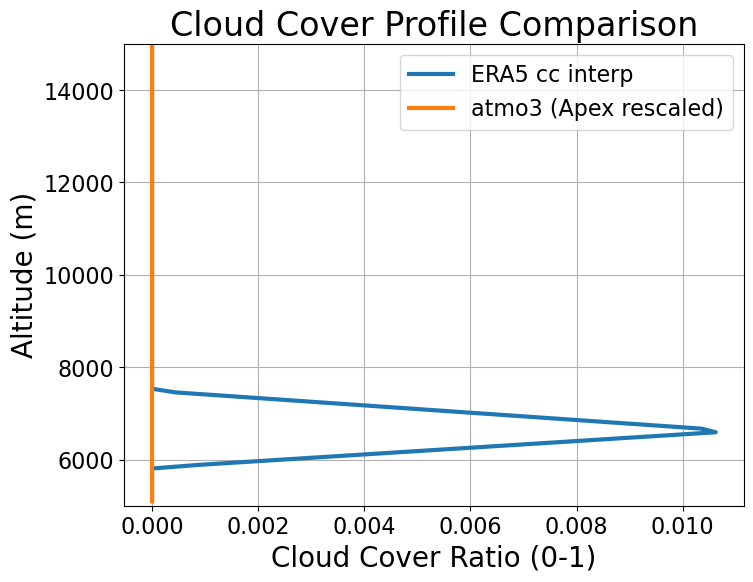

In [21]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp, altitude_profile, label='ERA5 cc interp')
#plt.plot(cc_ratio_atmo3, altitude_profile, label='atmo3 with std from ERA5 grid')
#plt.plot(cc_ratio_atmo3_rh_rescaled, altitude_profile, label='atmo3 with std from ERA5 grid (RH rescaled)')
plt.plot(cc_ratio_atmo3_rh_apex_rescaled, altitude_profile, label='atmo3 (Apex rescaled)')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Comparison')
plt.ylim(5000, 15000)
plt.legend()
plt.grid()
plt.show()

Let's do the grid method

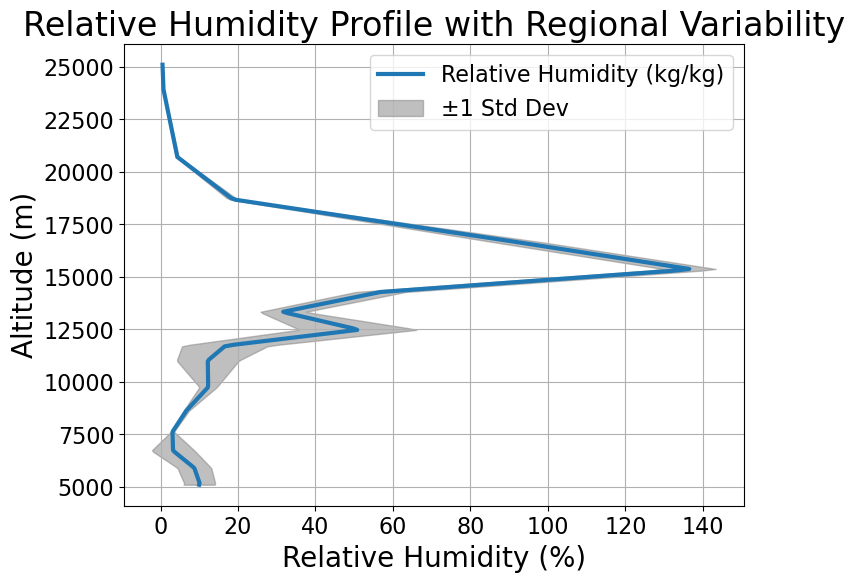

In [12]:
dataset_rh = xr.open_dataset(rhfile)

# 1. Calculate the regional standard deviation (all 81 points) for ALL times and levels
std_rh_regional_full = dataset_rh['r'].std(dim=['latitude', 'longitude'], ddof=1)

# 2. Extract your specific time
# We use .replace(tzinfo=None) to make it timezone-naive so it perfectly matches xarray's datetime64
std_rh_date = std_rh_regional_full.sel(time=time_utc.replace(tzinfo=None)).values

std_rh_reversed = std_rh_date[::-1]

# 2. Interpolate using the same logic found inside atmo3.super_grid
std_rh_interp = jnp.interp(
    atmo_box22sep.super_grid.z,             # Target x: Simulation altitude grid
    atmo_box22sep.super_grid.zgeo_atsite,   # Source x: ERA5 geopotential heights at the site
    std_rh_reversed,                    # Source y: Your reversed standard deviation array
    left='extrapolate', 
    right='extrapolate'
)

plt.figure(figsize=(8, 6))
plt.plot(rh_interp, altitude_profile, label='Relative Humidity (kg/kg)')
plt.fill_betweenx(altitude_profile, rh_interp - std_rh_interp, rh_interp + std_rh_interp, color='gray', alpha=0.5, label='±1 Std Dev')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Altitude (m)')
plt.title('Relative Humidity Profile with Regional Variability')
plt.legend()
plt.grid()
plt.show()

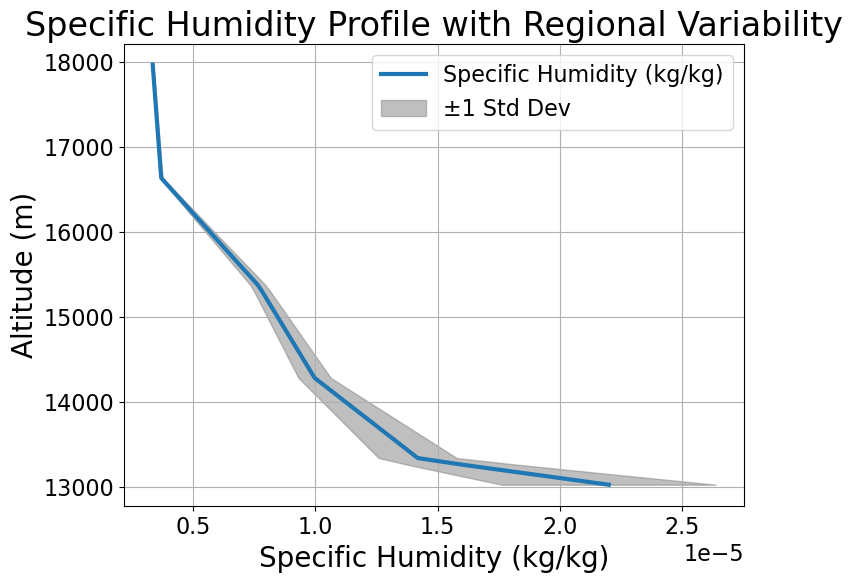

In [13]:
dataset_q = xr.open_dataset(spechfile)
std_q_regional_full = dataset_q['q'].std(dim=['latitude', 'longitude'], ddof=1)

# 2. Extract your specific time
# We use .replace(tzinfo=None) to make it timezone-naive so it perfectly matches xarray's datetime64
std_q_date = std_q_regional_full.sel(time=time_utc.replace(tzinfo=None)).values

std_q_reversed = std_q_date[::-1]

# 2. Interpolate using the same logic found inside atmo3.super_grid
std_q_interp = jnp.interp(
    atmo_box22sep.super_grid.z,             # Target x: Simulation altitude grid
    atmo_box22sep.super_grid.zgeo_atsite,   # Source x: ERA5 geopotential heights at the site
    std_q_reversed,                    # Source y: Your reversed standard deviation array
    left='extrapolate', 
    right='extrapolate'
)
#we do a mask to only see altitude between (13000m and 18000m)
mask = (altitude_profile >= 13000) & (altitude_profile <= 18000)

plt.figure(figsize=(8, 6))
plt.plot(q_interp[mask], altitude_profile[mask], label='Specific Humidity (kg/kg)')
plt.fill_betweenx(altitude_profile[mask], q_interp[mask] - std_q_interp[mask], q_interp[mask] + std_q_interp[mask], color='gray', alpha=0.5, label='±1 Std Dev')
plt.xlabel('Specific Humidity (kg/kg)')
plt.ylabel('Altitude (m)')
plt.title('Specific Humidity Profile with Regional Variability')
plt.legend()
plt.grid()
plt.show()

In [14]:
seed = 123456789


# 1. Define your fluctuation scaling (zscale) as you suggested
custom_zscale = {'h': altitude_profile, 'f': std_q_interp}

# 2. Define your mean profile 
# (Assuming raw_specific_humidity is the un-calibrated ERA5 profile we got earlier)
custom_mean = {'h': altitude_profile, 'f': q_interp}

# 3. Add the component using the internal _add_component method
atmo_box22sep._add_component(
    field_name='q',                  # The name of your custom component
    field_unit='kg/kg',              # The physical unit
    pspec=pspec_q,                # Your power spectrum dict (e.g., {'k': k_array, 'pofk': pofk})
    zscale=custom_zscale,            # Scales the RMS amplitude of the fluctuations
    mean=custom_mean,                # Adds the background mean profile
    seed=seed                  # A unique random seed for this component
)

atmo_box22sep.generate_realization(time_step=0, component_name='q')

# Extract your final 3D JAX arrays
q_variations_cube_q_rescaled = atmo_box22sep.components['q'].field


seed = 123456789


# 1. Define your fluctuation scaling (zscale) as you suggested
custom_zscale_rh = {'h': altitude_profile, 'f': std_rh_interp}

# 2. Define your mean profile 
# (Assuming raw_specific_humidity is the un-calibrated ERA5 profile we got earlier)
custom_mean_rh = {'h': altitude_profile, 'f': rh_interp}

# 3. Add the component using the internal _add_component method
atmo_box22sep._add_component(
    field_name='rh',                  # The name of your custom component
    field_unit='%',              # The physical unit
    pspec=pspec_q,                # Your power spectrum dict (e.g., {'k': k_array, 'pofk': pofk})
    zscale=custom_zscale_rh,            # Scales the RMS amplitude of the fluctuations
    mean=custom_mean_rh,                # Adds the background mean profile
    seed=seed                  # A unique random seed for this component
)

atmo_box22sep.generate_realization(time_step=0, component_name='rh')

# Extract your final 3D JAX arrays
rh_variations_cub_rh_rescaled = atmo_box22sep.components['rh'].field

In [15]:
# for the q rescaled, we need to get the rh fluctations

virtual_temp1D = au.virtual_temperature(T=t_interp, q=q_interp)
water_rho1D = au.water_vapor_density(q=q_interp, P=p_interp, T_v=virtual_temp1D)
rh_mean1D = au.water_vapor_density_to_rel_humidity(rho_wv=water_rho1D, T=t_interp) * 100.0

T_3d = t_interp.reshape(1, 1, -1)
P_3d = p_interp.reshape(1, 1, -1)

# Here only due to fluctuations, we get a 3D q cube, we need to add the mean to get the total q cube
T_v_3d = au.virtual_temperature(T=T_3d, q=q_variations_cube_q_rescaled)

# 4. Calculate Water Vapor Density (rho_wv) in kg/m^3
rho_wv_3d = au.water_vapor_density(q=q_variations_cube_q_rescaled, P=P_3d, T_v=T_v_3d)

# 5. Calculate Relative Humidity
# Note: This function returns RH as a fraction (0.0 to 1.0)
rh_fraction_cube = au.water_vapor_density_to_rel_humidity(rho_wv=rho_wv_3d, T=T_3d)

# Convert to percentage (0% to 100%) if needed for your cloud cover checks
rh_percentage_cube = rh_fraction_cube * 100.0

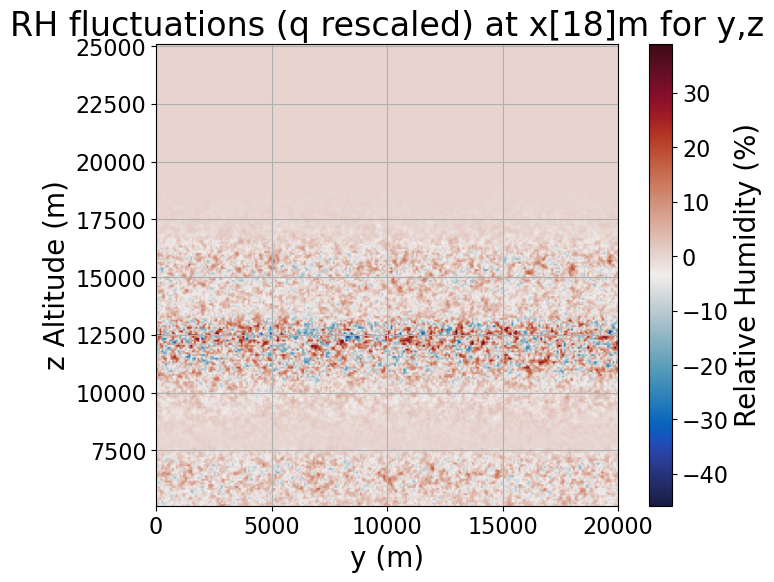

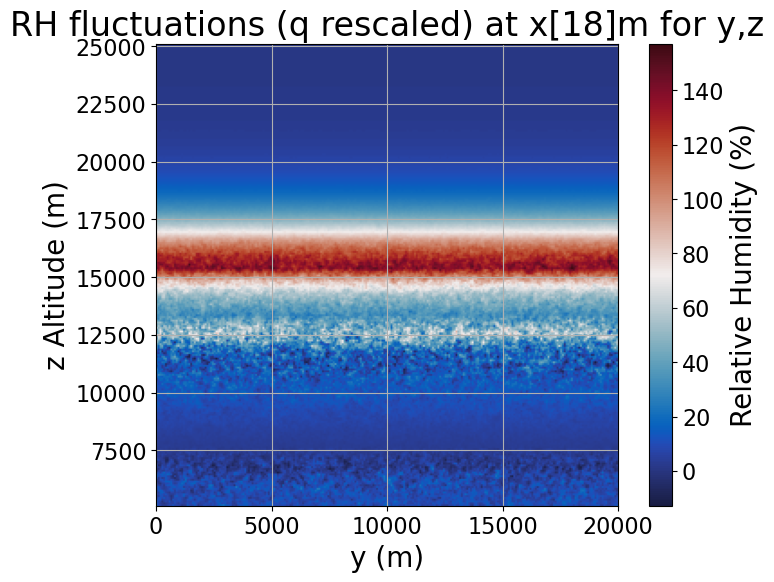

In [37]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_percentage_cube[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (q rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(rh_percentage_cube[18,:,:].T + rh_mean1D.reshape(1,1,-1)[18, :, :].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (q rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

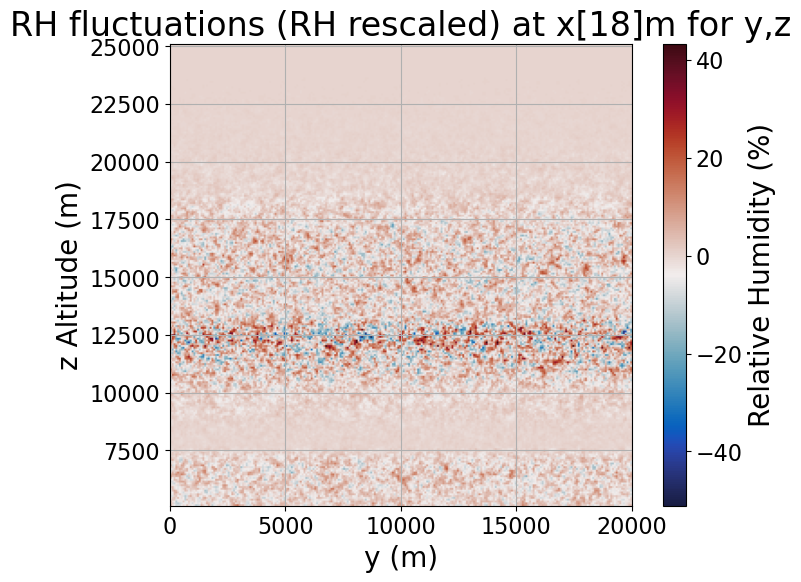

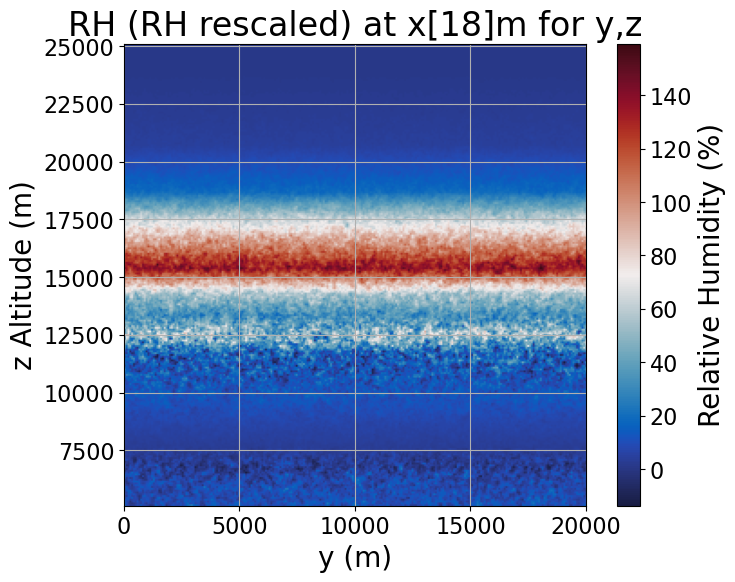

In [55]:
plt.figure(figsize=(8, 6))
plt.imshow(rh_variations_cub_rh_rescaled[18,:,:].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH fluctuations (RH rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(rh_variations_cub_rh_rescaled[18,:,:].T + rh_interp.reshape(1,1,-1)[18, :, :].T,extent=(0, box_length[1], site_altitude, site_altitude + box_length[2]),
    cmap=cmo.cm.balance, origin='lower')
plt.colorbar(label='Relative Humidity (%)')
plt.xlabel('y (m)')
plt.ylabel('z Altitude (m)')
plt.title('RH (RH rescaled) at x[18]m for y,z')
plt.grid()
plt.show()

In [16]:
# 2. Replace the hardcoded '1.0' with your new dynamic threshold
cloud_cube_q_rescaled = ((rh_percentage_cube+rh_interp.reshape(1,1,-1)) / 100.0 > dynamic_threshold_cube).astype(jnp.int32)

# 3. Calculate the mean exactly as you did before
cc_ratio_atmo3_q_rescaled = jnp.mean(cloud_cube_q_rescaled, axis=(0,1))


cloud_cube_rh_rescaled = ((rh_variations_cub_rh_rescaled+rh_interp.reshape(1,1,-1)) / 100.0 > dynamic_threshold_cube).astype(jnp.int32)

# 3. Calculate the mean exactly as you did before
cc_ratio_atmo3_rh_rescaled = jnp.mean(cloud_cube_rh_rescaled, axis=(0,1))


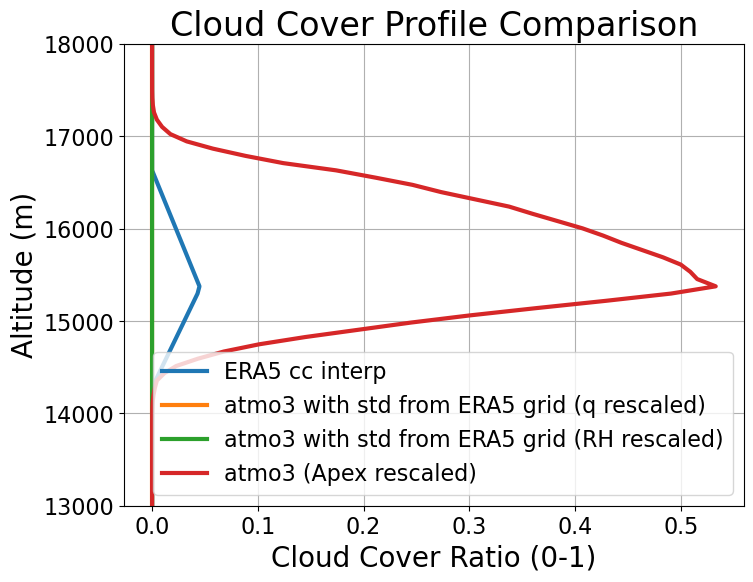

In [56]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp, altitude_profile, label='ERA5 cc interp')
plt.plot(cc_ratio_atmo3_q_rescaled, altitude_profile, label='atmo3 with std from ERA5 grid (q rescaled)')
plt.plot(cc_ratio_atmo3_rh_rescaled, altitude_profile, label='atmo3 with std from ERA5 grid (RH rescaled)')
plt.plot(cc_ratio_atmo3_rh_apex_rescaled, altitude_profile, label='atmo3 (Apex rescaled)')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Comparison')
plt.ylim(13000, 18000)
plt.legend()
plt.grid()
plt.show()

Let's try having a multiplying factor for the q profile

In [30]:
seed = 123456789


# 1. Define your fluctuation scaling (zscale) as you suggested
custom_zscale = {'h': altitude_profile, 'f': q_interp} # we generate fluctuations proportional to the mean profile then we multiply by a factor afterwards

# 2. Define your mean profile 
# (Assuming raw_specific_humidity is the un-calibrated ERA5 profile we got earlier)
custom_mean = {'h': altitude_profile, 'f': q_interp}

# 3. Add the component using the internal _add_component method
atmo_box22sep._add_component(
    field_name='proportional q',                  # The name of your custom component
    field_unit='kg/kg',              # The physical unit
    pspec=pspec_q,                # Your power spectrum dict (e.g., {'k': k_array, 'pofk': pofk})
    zscale=custom_zscale,            # Scales the RMS amplitude of the fluctuations
    mean=custom_mean,                # Adds the background mean profile
    seed=seed                  # A unique random seed for this component
)

atmo_box22sep.generate_realization(time_step=0, component_name='proportional q')

# Extract your final 3D JAX arrays
q_variations_cube_q_proportional_true = atmo_box22sep.components['proportional q'].field


In [46]:
# for the q rescaled, we need to get the rh fluctations
multiplying_factor = 0.115

q_variations_cube_q_proportional = q_variations_cube_q_proportional_true * multiplying_factor

virtual_temp1D = au.virtual_temperature(T=t_interp, q=q_interp)
water_rho1D = au.water_vapor_density(q=q_interp, P=p_interp, T_v=virtual_temp1D)
rh_mean1D = au.water_vapor_density_to_rel_humidity(rho_wv=water_rho1D, T=t_interp) * 100.0

T_3d = t_interp.reshape(1, 1, -1)
P_3d = p_interp.reshape(1, 1, -1)

# Here only due to fluctuations, we get a 3D q cube, we need to add the mean to get the total q cube
T_v_3d = au.virtual_temperature(T=T_3d, q=q_variations_cube_q_proportional)

# 4. Calculate Water Vapor Density (rho_wv) in kg/m^3
rho_wv_3d = au.water_vapor_density(q=q_variations_cube_q_proportional, P=P_3d, T_v=T_v_3d)

# 5. Calculate Relative Humidity
# Note: This function returns RH as a fraction (0.0 to 1.0)
rh_fraction_cube_q_proportional = au.water_vapor_density_to_rel_humidity(rho_wv=rho_wv_3d, T=T_3d)

# Convert to percentage (0% to 100%) if needed for your cloud cover checks
rh_percentage_cube_q_proportional = rh_fraction_cube_q_proportional * 100.0

In [47]:
# 2. Replace the hardcoded '1.0' with your new dynamic threshold
cloud_cube_q_proportional = ((rh_percentage_cube_q_proportional+rh_interp.reshape(1,1,-1)) / 100.0 > dynamic_threshold_cube).astype(jnp.int32)

# 3. Calculate the mean exactly as you did before
cc_ratio_atmo3_q_proportional = jnp.mean(cloud_cube_q_proportional, axis=(0,1))



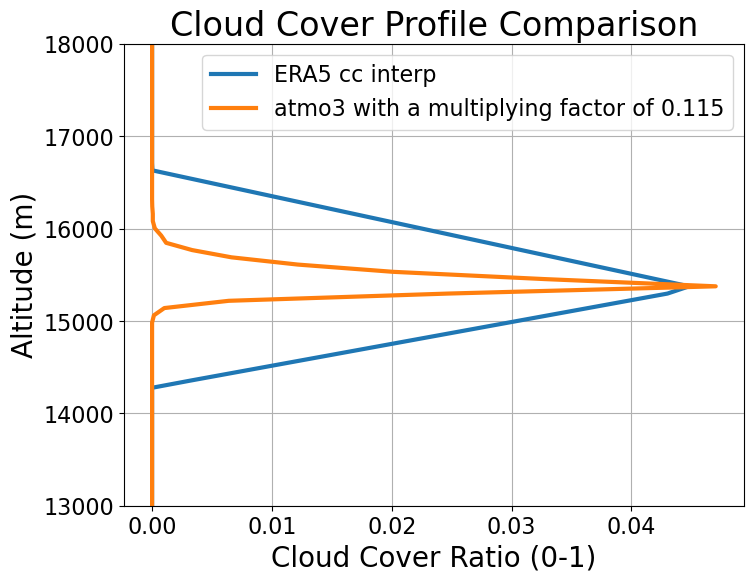

In [48]:
plt.figure(figsize=(8,6))
plt.plot(cc_interp, altitude_profile, label='ERA5 cc interp')
plt.plot(cc_ratio_atmo3_q_proportional, altitude_profile, label=f'atmo3 with a multiplying factor of {multiplying_factor}')
plt.xlabel('Cloud Cover Ratio (0-1)')
plt.ylabel('Altitude (m)')
plt.title('Cloud Cover Profile Comparison')
plt.ylim(13000, 18000)
plt.legend()
plt.grid()
plt.show()

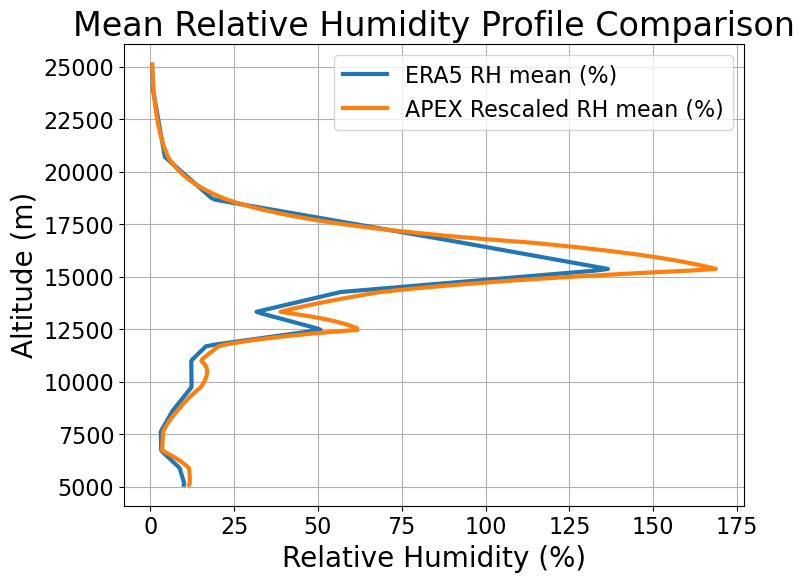

RH ERA5 mean at ground level (site altitude): 9.976447955005428
RH APEX rescaled mean at ground level (site altitude): 11.542308831599534


In [11]:
#quick comparison between the mean RH from ERA5 and the mean RH after the APEX rescaling

mean_dict = atmo_box22sep.component_mean['water vapor']

# The dictionary contains 'h' (height/altitude) and 'f' (the mean values)
rho_water_mean_1d = mean_dict['f'] #in kg/m^3

RH_mean_apex_rescaled = au.water_vapor_density_to_rel_humidity(rho_wv= rho_water_mean_1d, T=t_interp) * 100.0


plt.figure(figsize=(8, 6))
plt.plot(rh_interp, altitude_profile, label='ERA5 RH mean (%)')
plt.plot(RH_mean_apex_rescaled, altitude_profile, label='APEX Rescaled RH mean (%)')
plt.xlabel('Relative Humidity (%)')
plt.ylabel('Altitude (m)')
plt.title('Mean Relative Humidity Profile Comparison')
plt.legend()
plt.grid()
plt.show()

print("RH ERA5 mean at ground level (site altitude):", rh_interp[0])
print("RH APEX rescaled mean at ground level (site altitude):", RH_mean_apex_rescaled[0])

Let's have a look at Apex

In [4]:
import pandas as pd

# 1. Define your target time and the +/- 30 minute window
# We remove timezone info to perfectly match pandas datetime parsing
t0 = pd.Timestamp(time_utc).replace(tzinfo=None)
t_start = t0 - pd.Timedelta(minutes=30)
t_end   = t0 + pd.Timedelta(minutes=30)

# 2. Read the APEX data in chunks to save memory
chunks = []
for chunk in pd.read_csv(
    apexfile,
    header=None,
    names=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed'],
    parse_dates=['UT'],
    chunksize=1024
):
    # Filter rows that fall within our 1-hour window
    chunk_filtered = chunk[(chunk['UT'] >= t_start) & (chunk['UT'] <= t_end)]
    if not chunk_filtered.empty:
        chunks.append(chunk_filtered)
        
# Combine the filtered chunks into a single DataFrame
apexdata = pd.concat(chunks) if chunks else pd.DataFrame(
    columns=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed']
)

# 3. Convert APEX temperature from Celsius to Kelvin (like atmo3 does)
apexdata['Temperature'] += 273.15

# 4. Extract the exact statistics atmo3 uses for calibration
apex_pwv_mean = apexdata['PWV'].mean()
apex_pwv_std  = apexdata['PWV'].std()
apex_temperature_mean = apexdata['Temperature'].mean()
apex_temperature_std  = apexdata['Temperature'].std()
apex_humidity_mean = apexdata['Humidity'].mean()
apex_humidity_std  = apexdata['Humidity'].std()

# 5. Print the raw dataframe and the calculated stats
print(f"--- APEX Data Window ({t_start} to {t_end}) ---")
display(apexdata) # Use print(apexdata) if not in a Jupyter Notebook

print("\n--- Calibration Stats used by atmo3 ---")
print(f"APEX Mean PWV: {apex_pwv_mean:.3f} mm, Std: {apex_pwv_std:.3f} mm")
print(f"APEX Mean Temp: {apex_temperature_mean:.3f} K, Std: {apex_temperature_std:.3f} K")
print(f"APEX Mean Humidity: {apex_humidity_mean:.3f} %, Std: {apex_humidity_std:.3f} %")

--- APEX Data Window (2023-09-22 17:30:00 to 2023-09-22 18:30:00) ---


,UT,PWV,Temperature,Humidity,Wind_Dir,Wind_Speed
8756405,2023-09-22 17:30:00,0.87,276.75,18.9,294,4.9
8756406,2023-09-22 17:31:00,0.86,276.85,18.3,279,7.8
8756407,2023-09-22 17:32:00,0.94,276.95,18.7,266,5.3
8756408,2023-09-22 17:33:00,1.00,277.65,17.5,288,8.5
8756409,2023-09-22 17:34:00,0.94,276.65,17.0,289,7.0
...,...,...,...,...,...,...
8756461,2023-09-22 18:26:00,0.96,275.95,19.1,255,6.8
8756462,2023-09-22 18:27:00,0.94,276.05,18.8,267,6.4
8756463,2023-09-22 18:28:00,1.08,276.15,18.4,252,5.4
8756464,2023-09-22 18:29:00,1.01,277.25,17.7,289,7.4



--- Calibration Stats used by atmo3 ---
APEX Mean PWV: 0.909 mm, Std: 0.106 mm
APEX Mean Temp: 277.066 K, Std: 0.556 K
APEX Mean Humidity: 17.974 %, Std: 0.633 %


In [64]:
import pandas as pd

# 1. Target time t0
t0 = pd.Timestamp(time_utc).replace(tzinfo=None)

# 2. Values for delta_t (in minutes) to evaluate
delta_t_values = np.arange(1, 300, 1, dtype=int)  # 10 values from 1 to 30 minutes

# Find the maximum delta_t to read from the file just once to save I/O time
max_delta_t = max(delta_t_values)
t_start_max = t0 - pd.Timedelta(minutes=max_delta_t)
t_end_max = t0 + pd.Timedelta(minutes=max_delta_t)

# 3. Read the APEX data for the largest time window needed
chunks = []
for chunk in pd.read_csv(
    apexfile,
    header=None,
    names=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed'],
    parse_dates=['UT'],
    chunksize=1024
):
    chunk_filtered = chunk[(chunk['UT'] >= t_start_max) & (chunk['UT'] <= t_end_max)]
    if not chunk_filtered.empty:
        chunks.append(chunk_filtered)

full_window_data = pd.concat(chunks) if chunks else pd.DataFrame(
    columns=['UT', 'PWV', 'Temperature', 'Humidity', 'Wind_Dir', 'Wind_Speed']
)

# Convert APEX temperature from Celsius to Kelvin
if not full_window_data.empty:
    full_window_data['Temperature'] += 273.15

results = []

# 4. Loop over each delta_t to compute parameters for a 2*delta_t window
for dt in delta_t_values:
    t_start = t0 - pd.Timedelta(minutes=dt)
    t_end   = t0 + pd.Timedelta(minutes=dt)
    
    # Filter data specific to this window size
    mask = (full_window_data['UT'] >= t_start) & (full_window_data['UT'] <= t_end)
    window_data = full_window_data[mask]
    
    if not window_data.empty:
        pwv_mean = window_data['PWV'].mean()
        sigma_pwv = window_data['PWV'].std()
        t_mean = window_data['Temperature'].mean()
        sigma_t = window_data['Temperature'].std()
    else:
        pwv_mean = sigma_pwv = t_mean = sigma_t = float('nan')
        
    results.append({
        'delta_t (min)': dt,
        'window (min)': 2 * dt,
        'PWV_mean': pwv_mean,
        'sigma_PWV': sigma_pwv,
        'T_mean': t_mean,
        'sigma_T': sigma_t
    })

# 5. Display the summary for all delta_t windows
#summary_df = pd.DataFrame(results)
#display(summary_df)

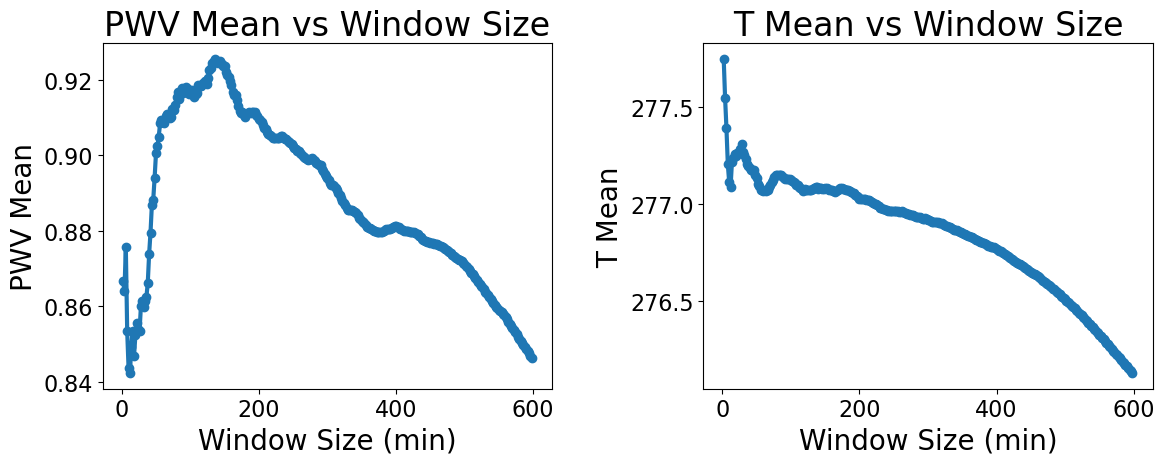

In [65]:
# 6. Plotting the results
results_df = pd.DataFrame(results)
#We just plot mean PWV and T as a function of delta_t
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results_df['window (min)'], results_df['PWV_mean'], marker='o')
plt.xlabel('Window Size (min)')
plt.ylabel('PWV Mean')
plt.title('PWV Mean vs Window Size')
plt.subplot(1, 2, 2)
plt.plot(results_df['window (min)'], results_df['T_mean'], marker='o')
plt.xlabel('Window Size (min)')
plt.ylabel('T Mean')
plt.title('T Mean vs Window Size')
plt.tight_layout()
plt.show()


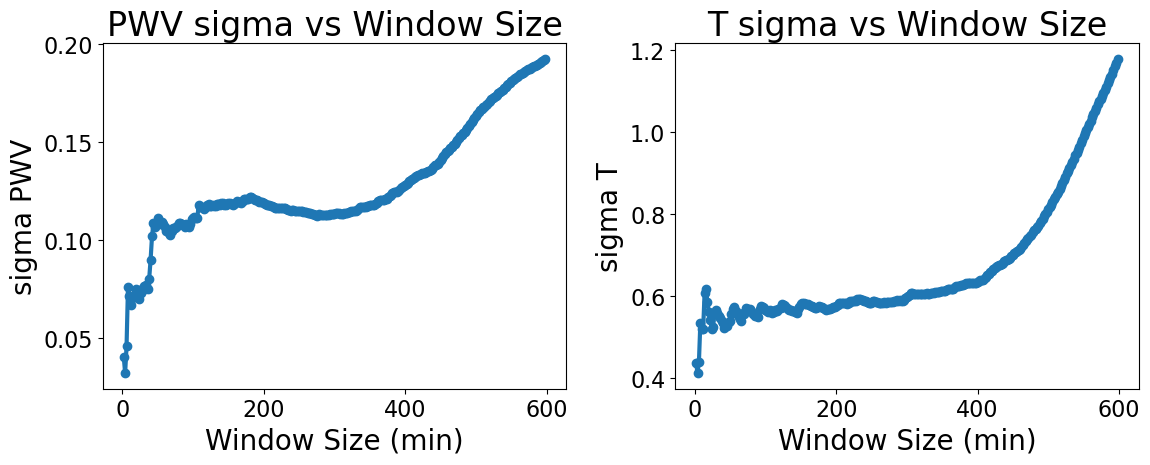

In [68]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results_df['window (min)'], results_df['sigma_PWV'], marker='o')
plt.xlabel('Window Size (min)')
plt.ylabel('sigma PWV')
plt.title('PWV sigma vs Window Size')
plt.subplot(1, 2, 2)
plt.plot(results_df['window (min)'], results_df['sigma_T'], marker='o')
plt.xlabel('Window Size (min)')
plt.ylabel('sigma T')
plt.title('T sigma vs Window Size')
plt.tight_layout()
plt.show()

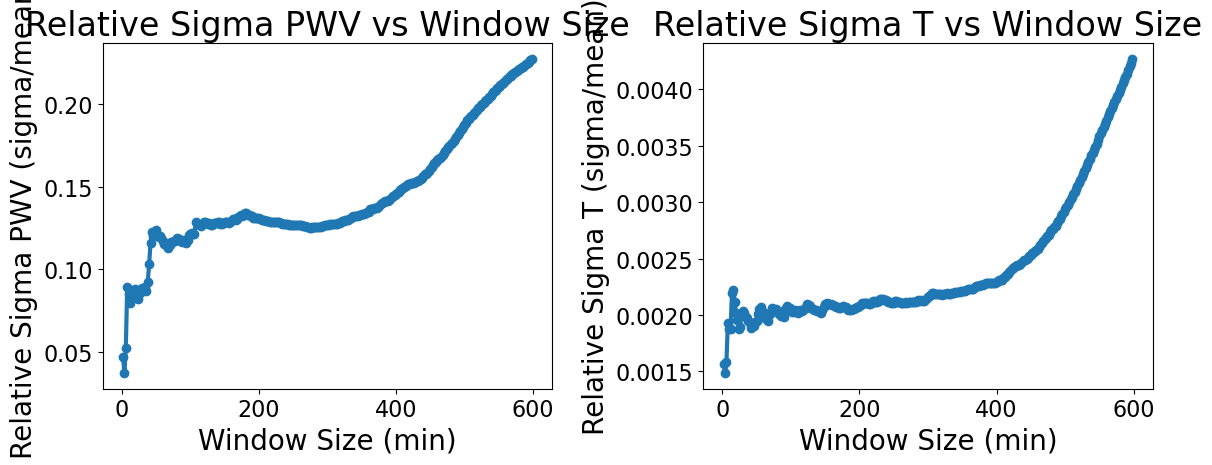

In [67]:
#Let's plot the relative sigma (sigma/mean) for both PWV and T
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(results_df['window (min)'], results_df['sigma_PWV'] / results_df['PWV_mean'], marker='o')
plt.xlabel('Window Size (min)')
plt.ylabel('Relative Sigma PWV (sigma/mean)')
plt.title('Relative Sigma PWV vs Window Size')
plt.subplot(1, 2, 2)
plt.plot(results_df['window (min)'], results_df['sigma_T'] / results_df['T_mean'], marker='o')
plt.xlabel('Window Size (min)')
plt.ylabel('Relative Sigma T (sigma/mean)')
plt.title('Relative Sigma T vs Window Size')
plt.tight_layout()
plt.show()